# Task 3: Interpret the Embedding Space

Analyze the effects of the perturbations by visualizing and interpreting the 
resulting embedding space. Consider metrics such as clustering, shifts in 
embedding coordinates, and neighborhood analysis to infer the impact of  perturbations on disease-associated gene networks.

The individual plots will be explained in separate markdown cells.



In [1]:
# Imports
%load_ext autoreload
%autoreload 2

import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from src.data import load_data, load_embeddings
from src.constants import RELEVANT_CELLTYPES

RESULTS_DIR = pathlib.Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)



/Users/tzehnder/dev/als-perturb/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data and embeddings
adata = load_data()
sub_index = pd.read_csv("../data/adata_sub_index.csv").squeeze()
adata_sub = adata[sub_index].copy()
obs = adata_sub.obs.reset_index(drop=True)
print(f"Loaded subset: {adata_sub.n_obs:,} cells")

embeddings = load_embeddings()
print(f"Available embeddings: {list(embeddings.keys())}")

sals_mask = (obs["Group"] == "SALS").values
pn_mask   = (obs["Group"] == "PN").values



Loaded: 112,014 cells × 22,832 genes
Loaded subset: 798 cells
Loaded 25 existing embeddings from /Users/tzehnder/dev/als-perturb/data/embeddings.pkl: ['baseline', 'MYT1L_down', 'MYT1L_up', 'REST_down', 'REST_up', 'SREBF2_down', 'SREBF2_up', 'LYNX1_down', 'LYNX1_up', 'TBR1_down', 'TBR1_up', 'KIF5A_down', 'KIF5A_up', 'DCTN1_down', 'DCTN1_up', 'DYNC1H1_down', 'DYNC1H1_up', 'TUBA4A_down', 'TUBA4A_up', 'NEFH_down', 'NEFH_up', 'TTC14_down', 'TTC14_up', 'HSP90AA1_down', 'HSP90AA1_up']
Available embeddings: ['baseline', 'MYT1L_down', 'MYT1L_up', 'REST_down', 'REST_up', 'SREBF2_down', 'SREBF2_up', 'LYNX1_down', 'LYNX1_up', 'TBR1_down', 'TBR1_up', 'KIF5A_down', 'KIF5A_up', 'DCTN1_down', 'DCTN1_up', 'DYNC1H1_down', 'DYNC1H1_up', 'TUBA4A_down', 'TUBA4A_up', 'NEFH_down', 'NEFH_up', 'TTC14_down', 'TTC14_up', 'HSP90AA1_down', 'HSP90AA1_up']


In [3]:
# Compute per-cell-type centroids from the baseline embedding, and perturbed
# sALS/PN centroids for every (gene, direction) pair. All downstream metrics
# are relative to the baseline sALS centroid of each cell type.
emb_baseline = embeddings["baseline"]

centroids = {}
for ct in RELEVANT_CELLTYPES:
    ct_mask = (obs["Cellstates_LVL3"] == ct).values
    centroids[(ct, "SALS")] = emb_baseline[sals_mask & ct_mask].mean(axis=0)
    centroids[(ct, "PN")]   = emb_baseline[pn_mask   & ct_mask].mean(axis=0)

pert_keys = [key for key in embeddings if key != "baseline"]

pert_centroids = {}
for key in pert_keys:
    gene, direction = key.rsplit("_", 1)
    emb_pert = embeddings[key]
    for ct in RELEVANT_CELLTYPES:
        ct_mask = (obs["Cellstates_LVL3"] == ct).values
        pert_centroids[(gene, direction, ct, "SALS")] = emb_pert[sals_mask & ct_mask].mean(axis=0)
        pert_centroids[(gene, direction, ct, "PN")]   = emb_pert[pn_mask   & ct_mask].mean(axis=0)



In [4]:
# Shared plot config
unique_genes = sorted({k.rsplit("_", 1)[0] for k in pert_keys})
gene_palette = {g: c for g, c in zip(unique_genes, plt.cm.tab20.colors)}
n_ct = len(RELEVANT_CELLTYPES)
ct_palette = dict(zip(RELEVANT_CELLTYPES, plt.cm.tab10.colors[:n_ct]))



## Plot 1: Baseline UMAP

A 2D UMAP of the unperturbed GeneFormer embeddings, coloured first by disease
group (sALS vs. PN) and then by cell type. The left panel is the key  diagnostic: if sALS and PN cells were well-separated, we would expect two distinct clusters. Instead they are heavily interleaved, meaning the sALS→PN centroid distance is small relative to within-group variance. This is the fundamental limitation of all downstream perturbation analysis: any perturbation effect must compete against this background noise.

The right panel confirms that GeneFormer *does* encode cell type well. The
three motor neuron subtypes form distinct regions. So the model is functioning as intended, it simply was not pre-trained to resolve disease state.



/Users/tzehnder/dev/als-perturb/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


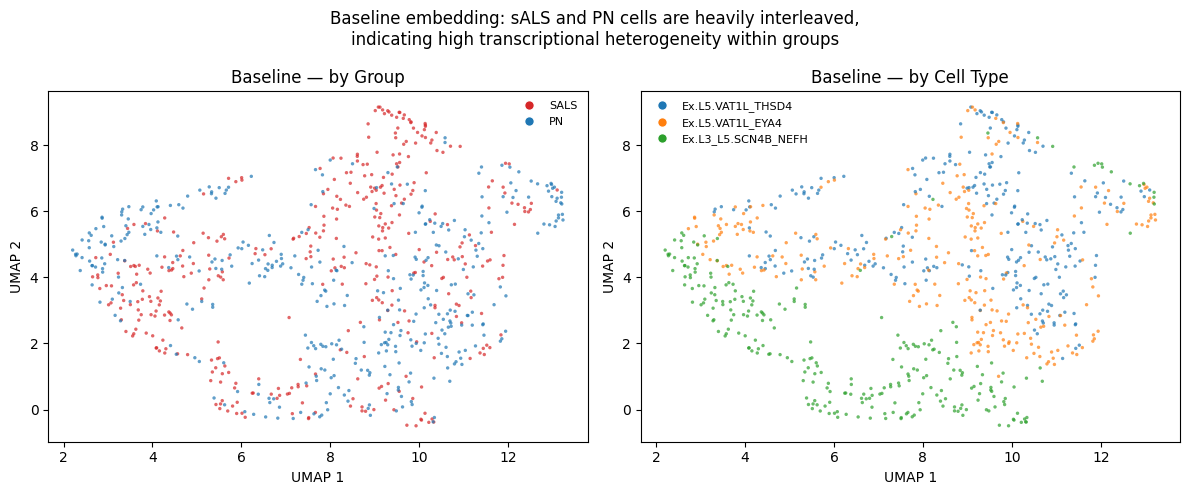

In [6]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric="cosine", random_state=42)
coords_baseline = reducer.fit_transform(emb_baseline)

group_palette    = {"SALS": "#d62728", "PN": "#1f77b4"}
ct_palette_umap  = dict(zip(RELEVANT_CELLTYPES, plt.cm.tab10.colors[:n_ct]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, palette, title in zip(
    axes,
    ["Group", "Cellstates_LVL3"],
    [group_palette, ct_palette_umap],
    ["Baseline — by Group", "Baseline — by Cell Type"],
):
    colors = [palette[v] for v in obs[col]]
    ax.scatter(coords_baseline[:, 0], coords_baseline[:, 1],
               c=colors, s=6, alpha=0.7, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    handles = [plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=c, markersize=7, label=l)
               for l, c in palette.items()]
    ax.legend(handles=handles, frameon=False, fontsize=8)
plt.suptitle(
    "Baseline embedding: sALS and PN cells are heavily interleaved,\n"
    "indicating high transcriptional heterogeneity within groups"
)
plt.tight_layout()
plt.savefig("../results/baseline_umap.png", dpi=150, bbox_inches="tight")
plt.show()



## Plot 2: Centroid shift along the sALS→PN axis

For each perturbation we define a disease axis as the vector from the baseline\ sALS centroid to the baseline PN centroid in the 512-dim embedding space. We then project the shift of the perturbed sALS centroid onto this axis and normalise by the total centroid distance, yielding a dimensionless score where +1 would mean the perturbed cells fully reached the PN centroid.

The heatmap shows this score for all 12 genes × 2 directions × 3 cell types.
Red = movement toward PN (potential rescue); blue = movement away.
Genes are sorted top-to-bottom by their mean score across all conditions.

**Key observation**: all values are ≤ 3% of the axis length, confirming that no perturbation produces a detectable rescue signal in the current embedding space.



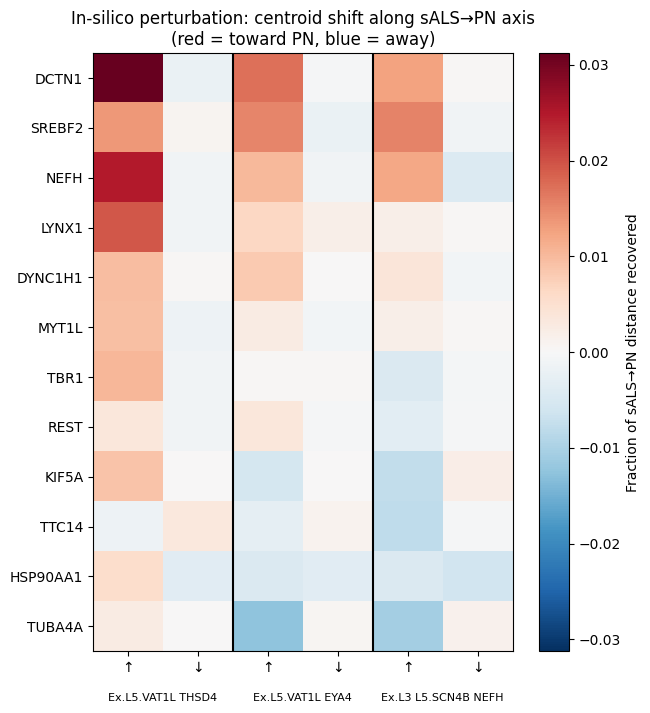

In [7]:
proj_rows = []
for ct in RELEVANT_CELLTYPES:
    sals_base  = centroids[(ct, "SALS")]
    pn_base    = centroids[(ct, "PN")]
    axis       = pn_base - sals_base
    axis_norm  = axis / np.linalg.norm(axis)
    axis_len   = np.linalg.norm(axis)

    for key in pert_keys:
        gene, direction = key.rsplit("_", 1)
        shift      = pert_centroids[(gene, direction, ct, "SALS")] - sals_base
        projection = np.dot(shift, axis_norm) / axis_len  # fraction of sALS→PN distance
        proj_rows.append({
            "celltype":   ct,
            "gene":       gene,
            "direction":  direction,
            "label":      gene + " " + direction,
            "axis_proj":  projection,
        })

proj_df = pd.DataFrame(proj_rows)

# Sort genes by mean projection across all conditions (best rescue at top)
gene_order = (
    proj_df.groupby("gene")["axis_proj"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Columns: (celltype, direction) pairs grouped by cell type
directions = ["up", "down"]
col_tuples = [(ct, d) for ct in RELEVANT_CELLTYPES for d in directions]

heatmap_data = (
    proj_df.pivot(index="gene", columns=["celltype", "direction"], values="axis_proj")
    .loc[gene_order, col_tuples]
)

abs_max = heatmap_data.values.__abs__().max()
n_cols   = len(col_tuples)

fig, ax = plt.subplots(figsize=(max(5, n_cols * 1.1), max(5, len(gene_order) * 0.6)))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdBu_r",
               vmin=-abs_max, vmax=abs_max)
plt.colorbar(im, ax=ax, label="Fraction of sALS→PN distance recovered")

ax.set_xticks(range(n_cols))
ax.set_xticklabels(
    ["↑" if d == "up" else "↓" for _, d in col_tuples],
    fontsize=10,
)
ax.set_yticks(range(len(gene_order)))
ax.set_yticklabels(gene_order)

for i, ct in enumerate(RELEVANT_CELLTYPES):
    x_frac = (i * len(directions) + (len(directions) - 1) / 2 + 0.5) / n_cols
    ax.text(x_frac, -0.07, ct.replace("_", " "), ha="center", va="top",
            fontsize=8, transform=ax.transAxes)

for i in range(1, n_ct):
    ax.axvline(i * len(directions) - 0.5, color="black", lw=1.5)

ax.set_title("In-silico perturbation: centroid shift along sALS→PN axis\n(red = toward PN, blue = away)")

plt.tight_layout()
plt.savefig("../results/axis_projection_scores.png", dpi=150, bbox_inches="tight")
plt.show()



## Plot 3: Structured 2D centroid projection

The same centroid shifts as Plot 2, but rendered as arrows in a 2D coordinate
system. The x-axis is the sALS->PN disease axis, the y-axis is the first principal component of the residual variance across all perturbed centroids, i.e. the direction of largest off-axis movement.

This plot adds one piece of information over Plot 2: the **magnitude of
off-axis (orthogonal) displacement**. An arrow that points strongly upward or
downward rather than rightward means the perturbation is doing something in the embedding space, but not in the disease direction. Arrows close to the origin indicate the perturbation has little effect at all.

In fact some perturbations do have a large effect, just not in the direction of the sALS->PN axis.


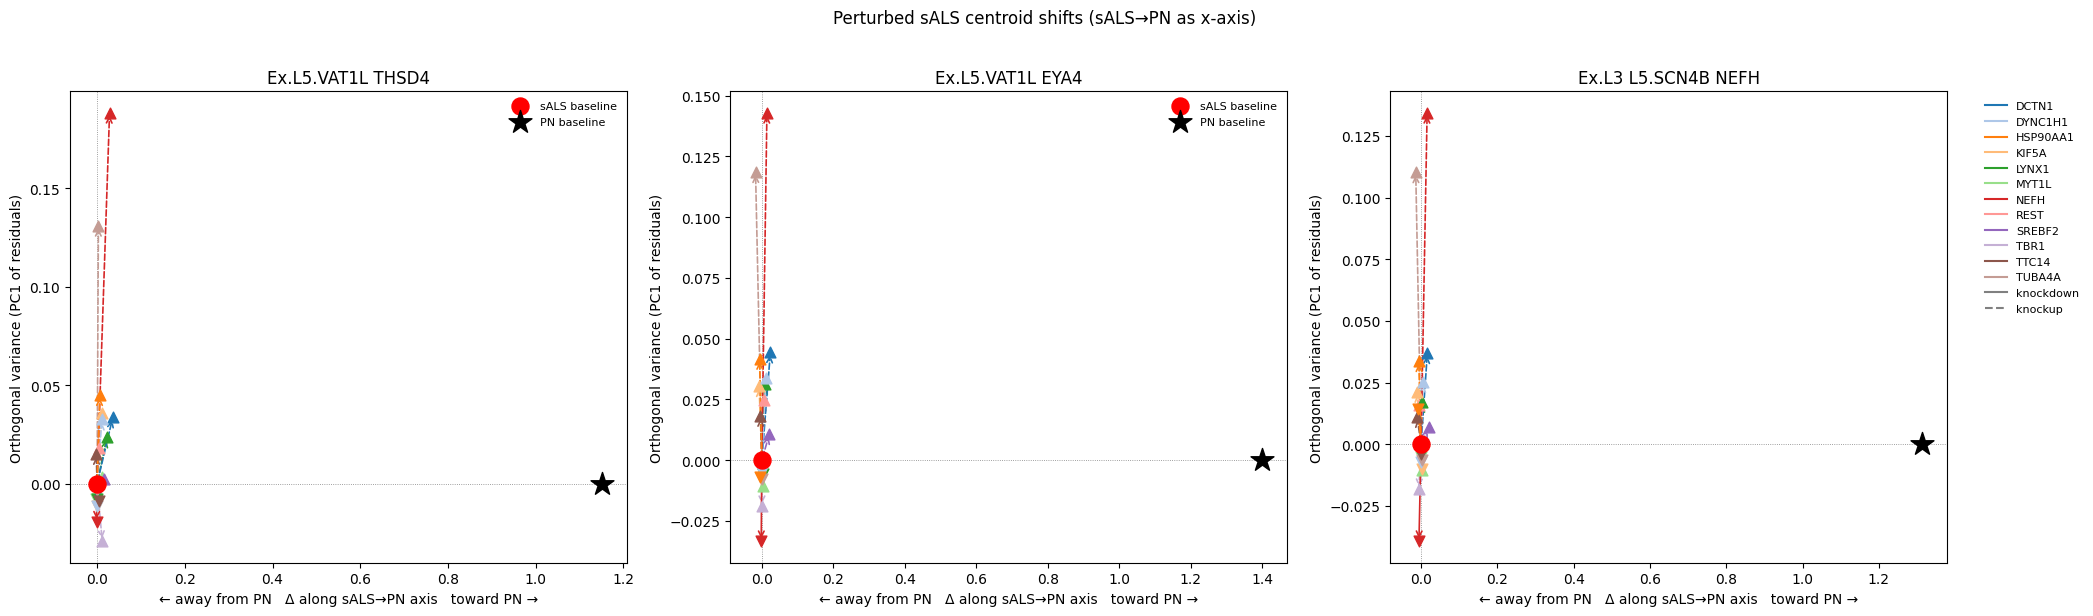

In [8]:
base_keys  = [(ct, group) for ct in RELEVANT_CELLTYPES for group in ("SALS", "PN")]
pert_c_keys = [
    (gene, direction, ct, "SALS")
    for key in pert_keys
    for gene, direction in [key.rsplit("_", 1)]
    for ct in RELEVANT_CELLTYPES
]

gene_handles = [plt.Line2D([0], [0], color=gene_palette[g], lw=1.5, label=g) for g in unique_genes]
dir_handles  = [
    plt.Line2D([0], [0], color="gray", lw=1.5, linestyle="-",  label="knockdown"),
    plt.Line2D([0], [0], color="gray", lw=1.5, linestyle="--", label="knockup"),
]

fig, axes = plt.subplots(1, n_ct, figsize=(7 * n_ct, 6))
if n_ct == 1:
    axes = [axes]

for ax, ct in zip(axes, RELEVANT_CELLTYPES):
    sals_base = centroids[(ct, "SALS")]
    pn_base   = centroids[(ct, "PN")]

    e1 = pn_base - sals_base
    e1 = e1 / np.linalg.norm(e1)

    pert_vecs = np.stack([
        pert_centroids[(gene, direction, ct, "SALS")]
        for key in pert_keys
        for gene, direction in [key.rsplit("_", 1)]
    ])

    residuals = pert_vecs - np.outer(pert_vecs @ e1, e1)
    pca = PCA(n_components=1)
    pca.fit(residuals)
    e2 = pca.components_[0]

    def project(v):
        return np.array([np.dot(v - sals_base, e1), np.dot(v - sals_base, e2)])

    origin  = project(sals_base)
    pn_proj = project(pn_base)

    ax.scatter(*origin,  color="red",   marker="o", s=150, zorder=5, label="sALS baseline")
    ax.scatter(*pn_proj, color="black", marker="*", s=300, zorder=5, label="PN baseline")
    ax.axvline(0, color="gray", lw=0.6, linestyle=":")
    ax.axhline(0, color="gray", lw=0.6, linestyle=":")

    for key in pert_keys:
        gene, direction = key.rsplit("_", 1)
        tip = project(pert_centroids[(gene, direction, ct, "SALS")])
        ax.annotate("", xy=tip, xytext=origin,
                    arrowprops=dict(arrowstyle="->", color=gene_palette[gene], lw=1.2,
                                   linestyle="-" if direction == "down" else "--"))
        ax.scatter(*tip, color=gene_palette[gene],
                   marker="v" if direction == "down" else "^", s=60, zorder=4)

    ax.set_title(ct.replace("_", " "))
    ax.set_xlabel("← away from PN   Δ along sALS→PN axis   toward PN →")
    ax.set_ylabel("Orthogonal variance (PC1 of residuals)")
    ax.legend(frameon=False, fontsize=8)

axes[-1].legend(handles=gene_handles + dir_handles, frameon=False,
                bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.suptitle("Perturbed sALS centroid shifts (sALS→PN as x-axis)", y=1.02)
plt.tight_layout()
plt.savefig("../results/perturbation_structured.png", dpi=150, bbox_inches="tight")
plt.show()



## Plot 4: Silhouette score per perturbation

The silhouette score measures how well-separated the sALS and PN clusters are
in the embedding space. A higher score means the two groups are more distinct; a lower score means they are more interleaved.

If a perturbation were successfully rescuing sALS cells toward a PN-like state, we would expect the silhouette score to *decrease*, the groups would become harder to tell apart. A score that remains unchanged (or increases) means the perturbation has not meaningfully altered the disease-state separation.

**Key observation**: all perturbations produce silhouette scores essentially
identical to the baseline (~0.06–0.08), confirming no perturbation meaningfully changes the global sALS/PN cluster structure.



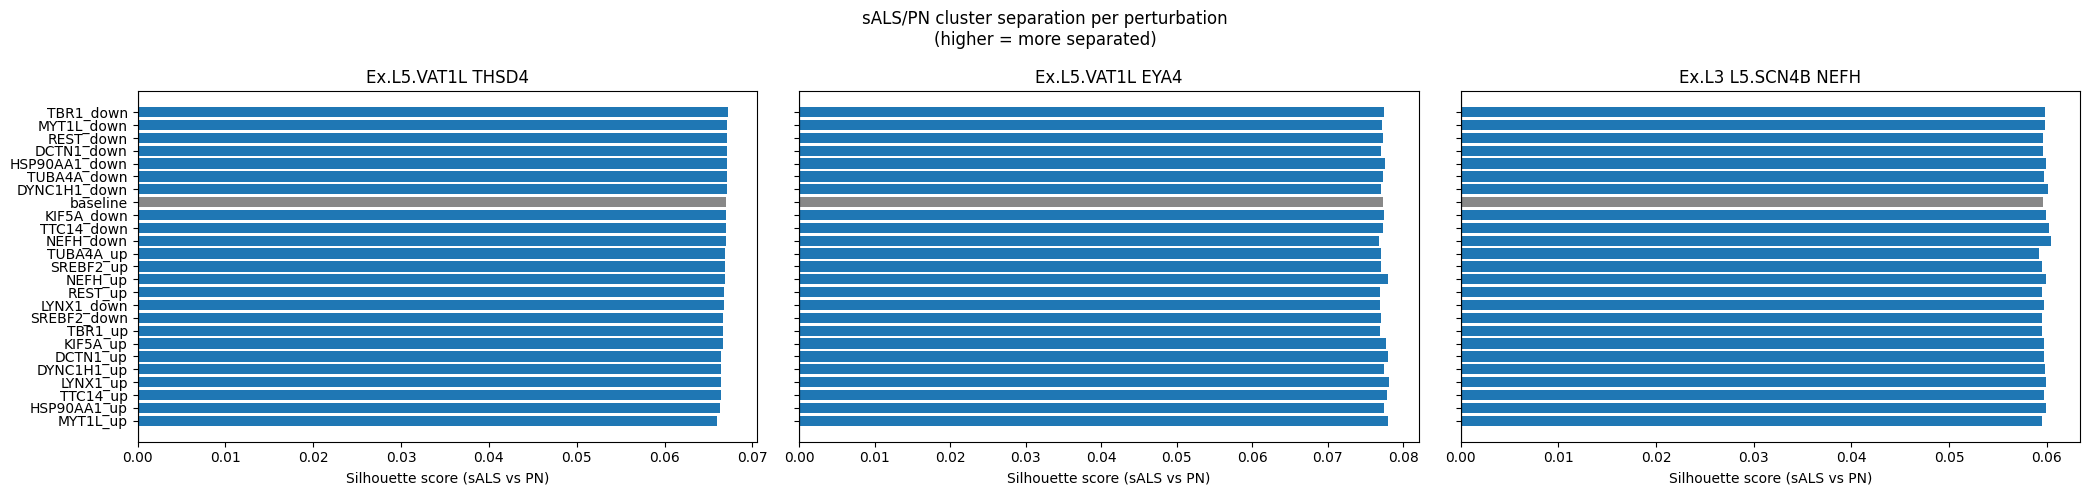

In [9]:
sil_rows = []
for key in embeddings:
    emb = embeddings[key]
    for ct in RELEVANT_CELLTYPES:
        ct_mask    = (obs["Cellstates_LVL3"] == ct).values
        X          = emb[ct_mask]
        labels_sil = obs.loc[ct_mask, "Group"].values
        score      = silhouette_score(X, labels_sil, metric="cosine")
        gene, direction = ("baseline", "") if key == "baseline" else key.rsplit("_", 1)
        sil_rows.append({
            "key": key, "gene": gene, "direction": direction,
            "celltype": ct, "silhouette": score,
        })

sil_df = pd.DataFrame(sil_rows)

fig, axes = plt.subplots(1, n_ct, figsize=(7 * n_ct, 5), sharey=True)
if n_ct == 1:
    axes = [axes]
for ax, ct in zip(axes, RELEVANT_CELLTYPES):
    sub    = sil_df[sil_df["celltype"] == ct].sort_values("silhouette", ascending=True)
    colors = ["#888888" if k == "baseline" else "#1f77b4" for k in sub["key"]]
    ax.barh(sub["key"], sub["silhouette"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(ct.replace("_", " "))
    ax.set_xlabel("Silhouette score (sALS vs PN)")
plt.suptitle("sALS/PN cluster separation per perturbation\n(higher = more separated)")
plt.tight_layout()
plt.savefig("../results/silhouette_scores.png", dpi=150, bbox_inches="tight")
plt.show()



## Plot 5: KNN neighborhood shift

A cell-level complement to the centroid-based Plot 2. For each sALS cell, we
find its K=20 nearest neighbors in the embedding space and measure what fraction are PN cells. We then compute the delta vs. the baseline fraction. A positive delta means sALS cells moved into a more PN-like local neighborhood after perturbation.

Unlike the centroid metric, this is sensitive to local geometry and does not
assume a single direction of movement. However, it is also more susceptible to noise when sALS and PN cells are heavily interleaved (as seen in Plot 1).

**Key observation**: the top genes in this plot do not agree with Plot 2, and
there is little consistency across cell types. Both metrics are effectively measuring noise in the absence of a strong disease-state signal in the embedding.



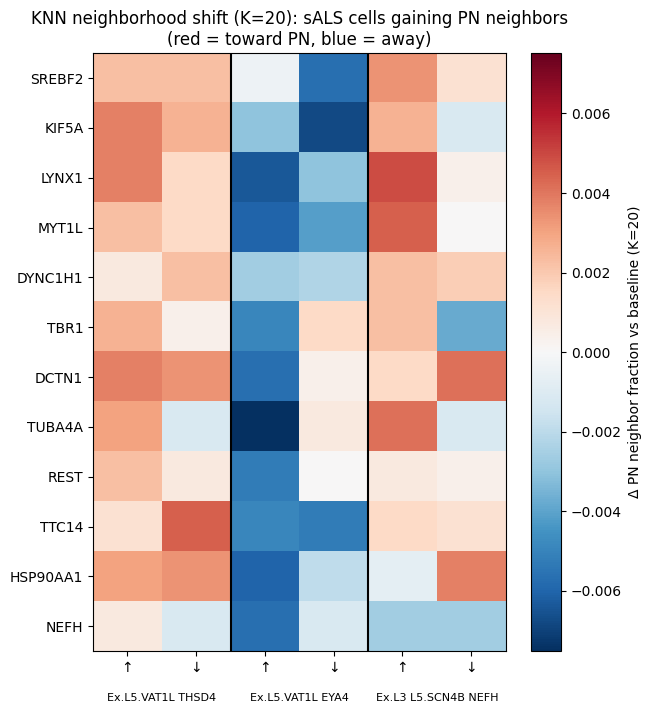

In [10]:
K = 20

def pn_neighbor_fraction(emb, ct_mask, sals_mask, pn_mask, k=K):
    X          = emb[ct_mask]
    local_sals = sals_mask[ct_mask]
    local_pn   = pn_mask[ct_mask]
    nbrs       = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(X)
    _, indices = nbrs.kneighbors(X[local_sals])
    return np.mean([local_pn[indices[i, 1:]].mean() for i in range(indices.shape[0])])

knn_rows = []
for key in embeddings:
    emb  = embeddings[key]
    gene, direction = ("baseline", "") if key == "baseline" else key.rsplit("_", 1)
    for ct in RELEVANT_CELLTYPES:
        ct_mask = (obs["Cellstates_LVL3"] == ct).values
        knn_rows.append({
            "key": key, "gene": gene, "direction": direction,
            "celltype": ct,
            "pn_neighbor_frac": pn_neighbor_fraction(emb, ct_mask, sals_mask, pn_mask),
        })

knn_df = pd.DataFrame(knn_rows)
baseline_frac = {
    ct: knn_df[(knn_df["key"] == "baseline") & (knn_df["celltype"] == ct)]["pn_neighbor_frac"].values[0]
    for ct in RELEVANT_CELLTYPES
}
knn_df["delta_pn_frac"] = knn_df.apply(
    lambda r: r["pn_neighbor_frac"] - baseline_frac[r["celltype"]], axis=1
)

knn_pert = knn_df[knn_df["key"] != "baseline"].copy()

knn_gene_order = (
    knn_pert[knn_pert["direction"] == "up"].groupby("gene")["delta_pn_frac"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)

knn_heatmap = (
    knn_pert.pivot(index="gene", columns=["celltype", "direction"], values="delta_pn_frac")
    .loc[knn_gene_order, col_tuples]
)

knn_abs_max = knn_heatmap.values.__abs__().max()

fig, ax = plt.subplots(figsize=(max(5, n_cols * 1.1), max(5, len(knn_gene_order) * 0.6)))
im = ax.imshow(knn_heatmap.values, aspect="auto", cmap="RdBu_r",
               vmin=-knn_abs_max, vmax=knn_abs_max)
plt.colorbar(im, ax=ax, label=f"Δ PN neighbor fraction vs baseline (K={K})")

ax.set_xticks(range(n_cols))
ax.set_xticklabels(["↑" if d == "up" else "↓" for _, d in col_tuples], fontsize=10)
ax.set_yticks(range(len(knn_gene_order)))
ax.set_yticklabels(knn_gene_order)

for i, ct in enumerate(RELEVANT_CELLTYPES):
    x_frac = (i * len(directions) + (len(directions) - 1) / 2 + 0.5) / n_cols
    ax.text(x_frac, -0.07, ct.replace("_", " "), ha="center", va="top",
            fontsize=8, transform=ax.transAxes)

for i in range(1, n_ct):
    ax.axvline(i * len(directions) - 0.5, color="black", lw=1.5)

ax.set_title(f"KNN neighborhood shift (K={K}): sALS cells gaining PN neighbors\n(red = toward PN, blue = away)")

plt.tight_layout()
plt.savefig("../results/knn_neighborhood.png", dpi=150, bbox_inches="tight")
plt.show()



## Plot 6: Per-cell axis projection distributions

The centroid shift in Plot 2 could in principle be driven by a small subset of cells. This plot shows the full distribution of individual sALS cell projections onto the sALS→PN axis for the top-5 genes by mean absolute axis projection.

The x-axis is normalized so that x=0 is the baseline sALS centroid and x=1 is
the baseline PN centroid. Gray = unperturbed baseline; blue = knockdown; red = knockup.

**Key observation**: the individual cell distributions span roughly -1.5 to +2.5,  a range 3–4× wider than the entire sALS→PN axis (0 to 1). This makes the within-group cell-to-cell variance strikingly visible and explains why centroid shifts of a few percent are undetectable against this background. A successful rescue perturbation would need to shift the entire distribution rightward, not just nudge the mean.



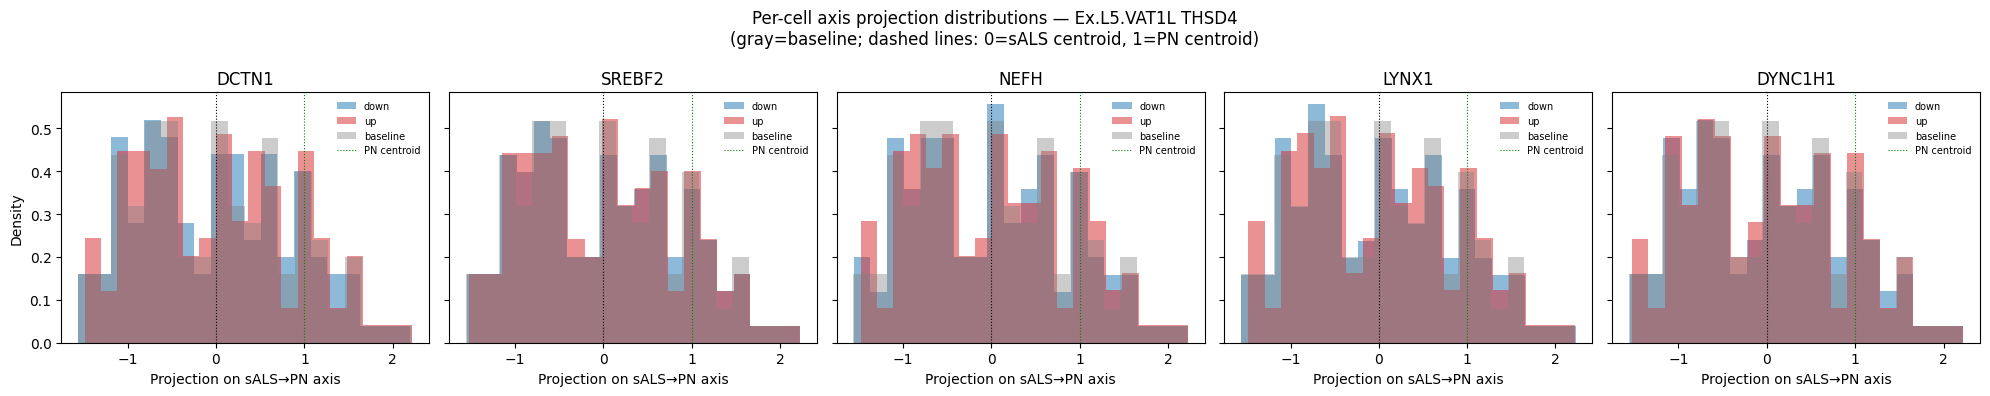

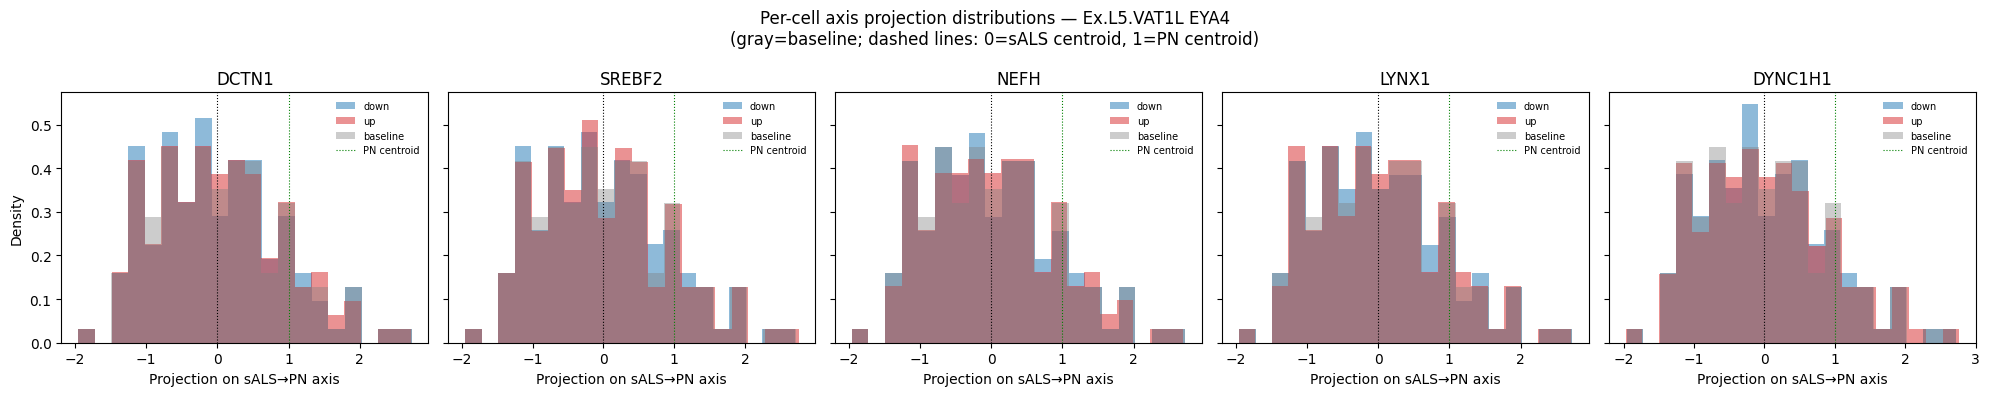

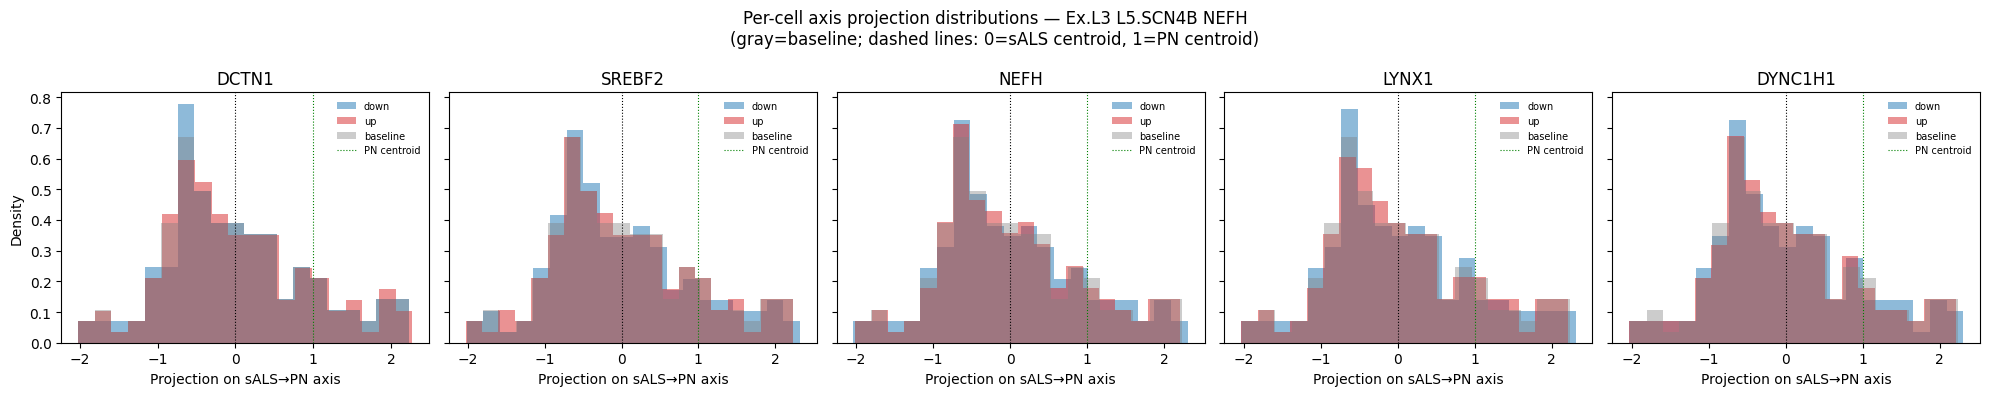

In [11]:
# Limit to top-5 genes by mean absolute axis projection for readability
top_genes = (
    proj_df.groupby("gene")["axis_proj"].mean()
    .abs().sort_values(ascending=False)
    .head(5).index.tolist()
)

for ct in RELEVANT_CELLTYPES:
    ct_mask   = (obs["Cellstates_LVL3"] == ct).values
    sals_base = centroids[(ct, "SALS")]
    pn_base   = centroids[(ct, "PN")]
    axis      = pn_base - sals_base
    axis_norm = axis / np.linalg.norm(axis)
    axis_len  = np.linalg.norm(axis)

    sals_ct_mask = sals_mask & ct_mask
    baseline_projs = (
        (emb_baseline[sals_ct_mask] - sals_base) @ axis_norm
    ) / axis_len

    fig, axes = plt.subplots(1, len(top_genes), figsize=(4 * len(top_genes), 4), sharey=True)
    for ax, gene in zip(axes, top_genes):
        for direction in ("down", "up"):
            key = f"{gene}_{direction}"
            if key not in embeddings:
                continue
            emb_pert = embeddings[key]
            pert_projs = (
                (emb_pert[sals_ct_mask] - sals_base) @ axis_norm
            ) / axis_len
            ax.hist(pert_projs, bins=20, alpha=0.5,
                    label=f"{direction}", density=True,
                    color="#d62728" if direction == "up" else "#1f77b4")

        ax.hist(baseline_projs, bins=20, alpha=0.4, density=True,
                color="gray", label="baseline")
        ax.axvline(0, color="black", lw=0.8, linestyle=":")
        ax.axvline(1, color="green", lw=0.8, linestyle=":", label="PN centroid")
        ax.set_title(gene)
        ax.set_xlabel("Projection on sALS→PN axis")
        ax.legend(fontsize=7, frameon=False)

    axes[0].set_ylabel("Density")
    plt.suptitle(
        f"Per-cell axis projection distributions — {ct.replace('_', ' ')}\n"
        "(gray=baseline; dashed lines: 0=sALS centroid, 1=PN centroid)"
    )
    plt.tight_layout()
    plt.savefig(f"../results/per_cell_proj_{ct}.png", dpi=150, bbox_inches="tight")
    plt.show()



## Overall interpretation

All three metrics (centroid axis projection, KNN neighborhood shift, per-cell
distributions) converge on the same conclusion: **no perturbation produces a
detectable rescue signal** in the GeneFormer embedding space.

This is not necessarily a biological null result. The most likely explanation is a measurement resolution problem: GeneFormer was pre-trained to encode cell *type* identity, not disease state. The sALS→PN axis is very short relative to within-group variance (silhouette ~0.07), so even a biologically real perturbation effect would be undetectable.

The path forward is **disease-state fine-tuning**: adding a classification head (sALS vs. PN) on top of the frozen GeneFormer weights and fine-tuning on the labelled cells in this dataset. This would reshape the latent space so that sALS and PN become the primary axis of variation, making centroid shifts and neighborhood analysis meaningful. This is the core value proposition of disease-specific foundation model fine-tuning that Helical offers.



In [12]:
# Save metric DataFrames for use in Task 4
proj_df.to_csv("../data/proj_df.csv", index=False)
knn_df.to_csv("../data/knn_df.csv", index=False)
sil_df.to_csv("../data/sil_df.csv", index=False)
print("Saved: proj_df.csv, knn_df.csv, sil_df.csv")


Saved: proj_df.csv, knn_df.csv, sil_df.csv
